# Lecture: Learning the Gaussian distribution

In this lecture, we will study one of the most fundamental probability distributions in statistics and machine learning: the Gaussian distribution, also known as the normal distribution. Despite its simple mathematical form, it plays a central role in modeling real-world data and forms the foundation of many learning algorithms.

To keep things intuitive, we analyze the one-dimensional (1D) case. Suppose we observe a set of real-valued data points, such as measurements of temperature, sensor noise, or exam scores. We assume that these observations were generated from a Gaussian distribution with unknown parameters. Our goal is to learn these parameters from the data.

Run the following cell only if you are working with google colab to copy the required .py file in the root directory. If you are working locally just ignore this cell!

In [27]:
!git clone https://github.com/Fjoelsak/AIBIP.git
!cp AIBIP/06-Generative_Image_Models/Gaussian1D.py ./

Cloning into 'AIBIP'...
Der Befehl "cp" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


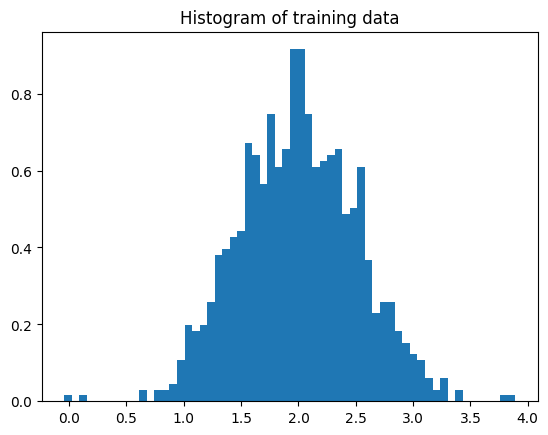

In [28]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from Gaussian1D import Gaussian1D

# -----------------------------------
# Generate synthetic training data
# -----------------------------------
true_mu = 2.0
true_sigma = 0.5

# Sample 1000 data points from a standard normal distribution (mean=0, std=1),
# scale them by true_sigma and shift them by true_mu
# -> This creates samples from N(true_mu, true_sigma^2)
data = torch.randn(1000) * true_sigma + true_mu

# -----------------------------------
# Visualize the generated data
# -----------------------------------
plt.hist(data, density=True, bins=60)
plt.title('Histogram of training data')
plt.show()

## Training using MLE

In [29]:
model = Gaussian1D()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# Training
# Log for the loss
loss_history = []
for i in range(500):

    optimizer.zero_grad()  # Reset gradients from previous step

    # Negative log-likelihood (we minimize it!)
    loss = -model.log_likelihood(data).mean()

    loss.backward()  # Compute gradients via backpropagation
    optimizer.step()  # Update parameters

    loss_history.append(loss.item())

print("Learned mu:", model.mu.item())
print("Learned sigma:", torch.exp(0.5 * model.log_var).item())

Learned mu: 1.9988383054733276
Learned sigma: 0.5115036964416504


## Plotting results (loss, true vs learned distribution)

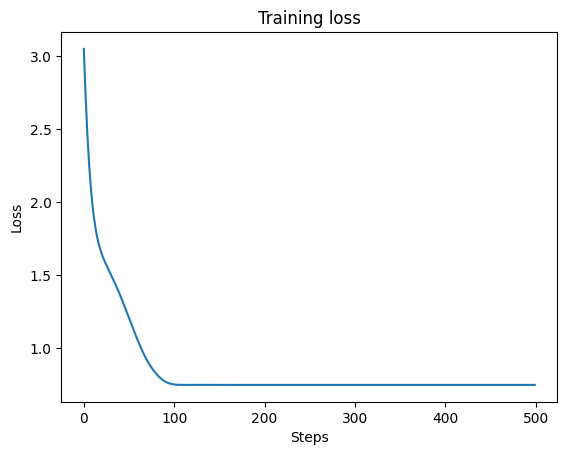

In [30]:
# Plotting the loss
plt.plot(loss_history)
plt.title('Training loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.show()

In [31]:
import math

learned_mu = model.mu.item()
learned_sigma = torch.exp(0.5 * model.log_var).item()

# Fine grid
x = torch.linspace(-1, 5, 1000)

# True density
true_density = (1 / (true_sigma * math.sqrt(2 * math.pi))) * \
               torch.exp(-(x - true_mu)**2 / (2 * true_sigma**2))

# Learned density
learned_density = (1 / (learned_sigma * math.sqrt(2 * math.pi))) * \
                  torch.exp(-(x - learned_mu)**2 / (2 * learned_sigma**2))

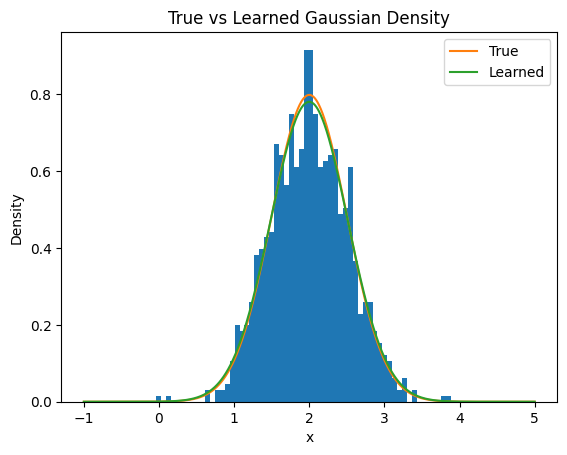

In [32]:
plt.figure()
plt.hist(data.numpy(), bins=60, density=True)
plt.plot(x.numpy(), true_density.numpy())
plt.plot(x.numpy(), learned_density.detach().numpy())
plt.title("True vs Learned Gaussian Density")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend(["True", "Learned"])
plt.show()